In [ ]:
import openai
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score

In [ ]:
# Load your saved pickle files
test_x = pd.read_pickle('/content/drive/MyDrive/master year 1 section 2/advance ML/project/workspace/Dataset/processed/fold_llm/test_x.pkl') # (patients, timesteps, features)
test_y = pd.read_pickle('/content/drive/MyDrive/master year 1 section 2/advance ML/project/workspace/Dataset/processed/fold_llm/test_y.pkl') # ground truth labels
test_pid = pd.read_pickle('/content/drive/MyDrive/master year 1 section 2/advance ML/project/workspace/Dataset/processed/fold_llm/test_pid.pkl')
test_x_missing_masks = pd.read_pickle('/content/drive/MyDrive/master year 1 section 2/advance ML/project/workspace/Dataset/processed/fold_llm/test_x_missing_masks.pkl')
# Load all_features
all_features = pd.read_pickle("/content/drive/MyDrive/master year 1 section 2/advance ML/project/workspace/Dataset/processed/fold_llm/all_features.pkl")


In [ ]:
# define you API key here

In [ ]:
# Prompt template
# Function to format input
def build_prompt(patient_features_full, record_times):
    """
    patient_features_full: (timesteps, features+2) array (includes sex and age)
    record_times: number of visits
    """
    # Extract sex and age
    sex = 'male' if patient_features_full[0][0] == 1 else 'female'
    age = patient_features_full[0][1]
    patient_features = patient_features_full[:, 2:]  # remove sex and age

    # Create record times list
    record_time_list = ', '.join(str(i) for i in range(record_times))

    # Create feature detail block
    detail = ''
    for idx, feature_vec in enumerate(patient_features):
        feature_str = "\n".join([f"- {feature_name}: {value:.2f}" for feature_name, value in zip(all_features, feature_vec)])
        detail += f"Visit {idx+1}:\n{feature_str}\n\n"

    # Few-shot examples (directly inside the prompt)
    few_shot_examples = """
Example #1: (Healthy Patient)
The patient is a female, aged 45 years.
The patient had 4 visits that occurred at 0, 1, 2, 3.
Details of the features for each visit are as follows:
- Heart Rate: 78, 80, 76, 77
- Systolic blood pressure: 120, 122, 118, 119
- Oxygen saturation: 98, 98, 99, 98
- Respiratory rate: 16, 15, 16, 15
...
RESPONSE:
0.10

Example #2: (Moderate Risk Patient)
The patient is a male, aged 67 years.
The patient had 4 visits that occurred at 0, 1, 2, 3.
Details of the features for each visit are as follows:
- Heart Rate: 95, 100, 98, 102
- Systolic blood pressure: 105, 100, 95, 90
- Oxygen saturation: 92, 91, 89, 88
- Respiratory rate: 22, 24, 26, 28
...
RESPONSE:
0.55

Example #3: (High Risk Patient)
The patient is a female, aged 82 years.
The patient had 4 visits that occurred at 0, 1, 2, 3.
Details of the features for each visit are as follows:
- Heart Rate: 130, 135, 140, 145
- Systolic blood pressure: 85, 80, 78, 75
- Oxygen saturation: 85, 82, 80, 78
- Respiratory rate: 30, 32, 34, 36
...
RESPONSE:
0.92
"""


    # Full user prompt assembly
    user_prompt = f"""You are an experienced doctor in Intensive Care Unit (ICU) treatment.

I will provide you with medical information from multiple ICU visits of a patient, each characterized by a fixed number of features.

Present multiple visit data of a patient in one batch. Express each feature as a list of values, separated by commas. Missing values are represented as `nan`.

Your task is to assess the medical data and analyze the ICU visits to predict the probability that the patient will **NOT survive** their hospital stay.

Please respond with only a floating-point number between 0 and 1, where a higher number suggests a greater likelihood of death.

In situations where the data does not allow for a reasonable conclusion, respond with the phrase `I do not know` without any additional explanation.

{few_shot_examples}

Now please predict the patient below:
The patient is a {sex}, aged {age} years.
The patient had {record_times} visits that occurred at {record_time_list}.
Details of the features for each visit are as follows:

{detail}

Based on the patient information, predict the probability of death before discharge.

**Important: Output only a floating-point number between 0 and 1.**
**Important: Do NOT always output 0.5 unless truly uncertain.**
**If the patient appears healthy, predict a probability between 0.0 and 0.3.**
**If the patient appears moderately ill, predict a probability between 0.4 and 0.7.**
**If the patient appears severely ill, predict a probability between 0.8 and 1.0.**

Do not include any explanations or words. Just output the number.

RESPONSE:
"""
    return user_prompt


In [ ]:
# Predict with GPT-4
# client = openai.OpenAI(), use your api key here

# Then change your query_gpt4 function to include a system prompt
def query_gpt4(user_prompt):
    response = client.chat.completions.create(
        model="gpt-4-0613",
        messages=[
            {"role": "system", "content": "You are a medical assistant."},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.0,
        max_tokens=20
    )
    return response.choices[0].message.content

In [ ]:
from tenacity import retry, wait_fixed, stop_after_attempt

@retry(wait=wait_fixed(20), stop=stop_after_attempt(5))
def safe_query(prompt):
    return query_gpt4(prompt)

In [ ]:

# Run prediction loop
predictions = []
for i in tqdm(range(len(test_x))):
    patient_features_full = np.array(test_x[i])  # convert to np.array first!
    record_times = len(patient_features_full)
    prompt = build_prompt(patient_features_full, record_times)

    # ADD this to checking the prompt
    # print(prompt)
    # print("="*80)

    # gpt_output = query_gpt4(prompt)
    gpt_output = safe_query(prompt)

    # Simple parsing
    try:
        pred = float(gpt_output.strip()) / 100.0  # convert % to 0-1 probability
    except:
        pred = 0.5  # fallback if GPT response is weird

    predictions.append(pred)


100%|██████████| 96/96 [43:17<00:00, 27.06s/it]


In [ ]:
# Evaluate
# Flatten properly
y_true = np.array([patient_y[0][0] for patient_y in test_y]).astype(int)


# Now evaluate
acc = accuracy_score(y_true, (np.array(predictions) > 0.5).astype(int))  # threshold 0.5
auroc = roc_auc_score(y_true, predictions)  # use soft probabilities

print(f"Accuracy: {acc:.4f}")
print(f"AUROC: {auroc:.4f}")


Accuracy: 0.8854
AUROC: 0.7917


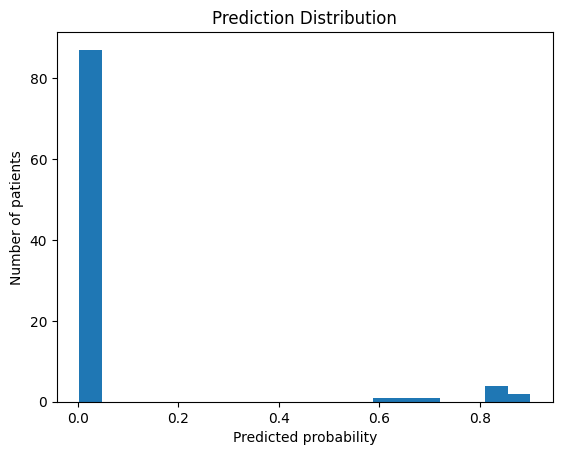

In [ ]:
import matplotlib.pyplot as plt

# Check distribution of predicted probabilities
plt.hist(predictions, bins=20)
plt.xlabel("Predicted probability")
plt.ylabel("Number of patients")
plt.title("Prediction Distribution")
plt.show()

# Also print a few predictions

Accuracy: 0.8854
AUROC: 0.7917
F1 Score: 0.4762


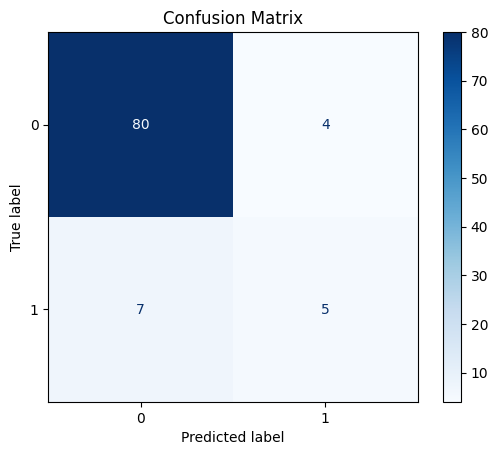

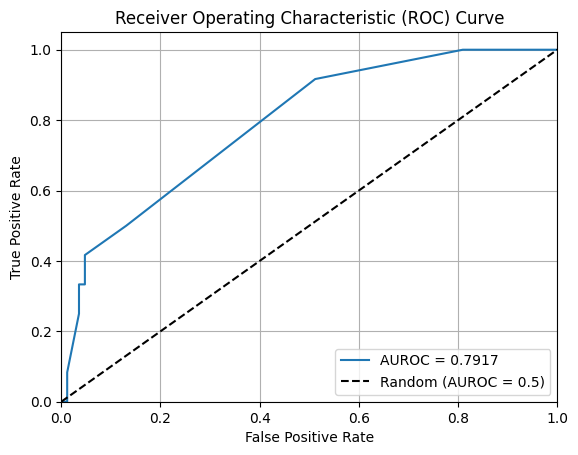

In [ ]:
import numpy as np
from sklearn.metrics import (
    roc_curve, auc,
    accuracy_score, roc_auc_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


#  Flatten y_true
y_true = np.array([patient_y[0][0] for patient_y in test_y]).astype(int)

#  Flatten predictions
predictions_array = np.array(predictions).flatten()

# Threshold predictions for classification metrics (e.g., F1, confusion matrix)
predicted_labels = (predictions_array > 0.5).astype(int)

# Metrics
acc = accuracy_score(y_true, predicted_labels)
auroc = roc_auc_score(y_true, predictions_array)  # Use probabilities for AUROC
f1 = f1_score(y_true, predicted_labels)

print(f"Accuracy: {acc:.4f}")
print(f"AUROC: {auroc:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, predictions_array)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUROC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUROC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()